In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 12
Total threads: 96,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41667,Workers: 12
Dashboard: http://127.0.0.1:8787/status,Total threads: 96
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:34423,Total threads: 8
Dashboard: http://127.0.0.1:36773/status,Memory: 83.91 GiB
Nanny: tcp://127.0.0.1:34693,


In [3]:
## Read in ITER 0 Diagnostics 
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import warnings
# warnings.filterwarnings("ignore")

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter0/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags+1,itPerFile)

prefix = ['diag_state']
tpose_ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
depths = tpose_ds.Z.values
lons = tpose_ds.XC.values
lats = tpose_ds.YC.values
T = len(tpose_ds.time)

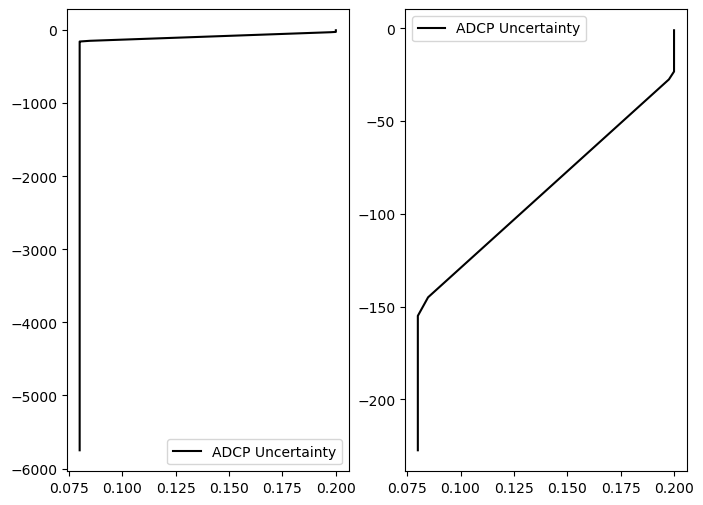

In [9]:
import numpy as np 

# Initialize the values array
uncertainty_adcp = np.zeros_like(depths)

# Region 1: Above 25 m (depth > -25 since depths are negative)
uncertainty_adcp[depths > -25] = 0.2

# Region 2: Between 25m and 150m (depth between -150 and -25)
mask = (depths <= -25) & (depths >= -150)
# Linear interpolation from 0.2 at -25 to 0.07 at -150
uncertainty_adcp[mask] = 0.2 + (0.08 - 0.2) * (depths[mask] + 25) / (-150 + 25)

# Region 3: Below 150m (depth < -150)
uncertainty_adcp[depths < -150] = 0.08

fig, ax = plt.subplots(figsize=(8, 6),ncols=2)
ax[0].plot(uncertainty_adcp, depths, 'k-', label='ADCP Uncertainty')
ax[0].legend()

ax[1].plot(uncertainty_adcp[:35], depths[:35], 'k-', label='ADCP Uncertainty')
ax[1].legend()

In [10]:
vel_weights = np.ones_like(tpose_ds.UVEL[0].values,dtype=np.float32) # set to 1/(0.05m/s)^2 , 5cm/s is the std dev of the velocity measurements
vel_weights.shape

(66, 336, 1128)

In [11]:
vel_weights = np.ones_like(tpose_ds.UVEL[0].values,dtype=np.float32) # set to 1/(0.05m/s)^2 , 5cm/s is the std dev of the velocity measurements
for k in range(len(depths)):
    vel_weights[k,:,:] = 1/(uncertainty_adcp[k]**2)

In [12]:
vel_weights.shape

(66, 336, 1128)

In [13]:
size_bytes = vel_weights.nbytes
print(f"Size: {size_bytes} bytes")
print(f"Size: {size_bytes / 1024:.2f} KB")

Size: 100058112 bytes
Size: 97713.00 KB


In [14]:
vel_weights.astype('>f4').tofile('/home/edavenport/analysis/TPOSE6_VelocityAssim/TAO_uvel_wt_tp6.bin')
vel_weights.astype('>f4').tofile('/home/edavenport/analysis/TPOSE6_VelocityAssim/TAO_vvel_wt_tp6.bin')

In [15]:
client.shutdown()